- Interval configured: 5 min
- Interval in 1 hour: 60 min /5 min
- Number of Intervals in 24 hours: 288

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from typing import List
import yaml as ym

In [2]:
!ls -l /home/projects/data

total 87020
-rwxrwxrwx 1 root root 89107856 Jan 25  2023 INTERVALDATA.csv


In [2]:
def load_config():
    # Read in the configuration file
    with open('../config.yaml') as p:
        config = ym.safe_load(p)
    return config

def cast_and_rename_columns(dataframe):
    dataframe["INTERVALDATE"] = pd.to_datetime(
        dataframe["INTERVALDATE"]
    )
    columns_mapping = {
        "'Published Packet'": "PUBLISHEDPACKET",
        "'Gap Analysis Packet'": "GAPREQPACKET",
    }
    dataframe = dataframe.rename(columns=columns_mapping)
    return dataframe
    
def process_missing_values(
    dataframe: pd.DataFrame,
    columns: List[str],
    processing_method: str = "remove",
    how: str = "any",
    value: int = -1000,
    order_by: str = "Data Hora",
):

    if processing_method == "remove":
        return dataframe.dropna(subset=columns, how=how)

    if processing_method == "replace":
        dataframe[columns] = dataframe[columns].fillna(value)
        return dataframe

    dataframe = dataframe.sort_values(order_by)

    if processing_method == "forward":
        dataframe[columns] = dataframe[columns].ffill()

    elif processing_method == "backward":
        dataframe[columns] = dataframe[columns].bfill()

    elif processing_method == "both":
        dataframe[columns] = dataframe[columns].ffill().bfill()

    else:
        raise ValueError(
            f"Processing method '{processing_method}' not implemented."
        )
    return dataframe

def create_information_columns(dataframe):
    dataframe["TOTALINTERVALS"] = (
        dataframe["PUBLISHEDPACKET"]
        + dataframe["GAPREQPACKET"]
    )
    dataframe["INFORMATION"] = np.where(
        dataframe["TOTALINTERVALS"] == 288,
        "Complete",
        "Incomplete",
    )
    dataframe["INFORMATIONPERCENT"] = (
        (dataframe["TOTALINTERVALS"] / 288) * 100
    ).round(2)
    return dataframe

def create_gapreq_efficiency_column(dataframe):
    dataframe["GAPREQEFFICIENCY"] = (
        (
            dataframe["GAPREQPACKET"]
            / (288 - dataframe["PUBLISHEDPACKET"])
        ) * 100
    ).round(2)
    return dataframe

import pandas as pd

def convert_meterno_to_string(dataframe):
    dataframe["METERNO"] = dataframe["METERNO"].astype(object)

    numeric_mask = pd.to_numeric(
        dataframe["METERNO"],
        errors="coerce"
    ).notna()
    dataframe.loc[numeric_mask, "METERNO"] = (
        pd.to_numeric(
            dataframe.loc[numeric_mask, "METERNO"]
        )
        .astype("Int64")
        .astype(str)
    )
    return dataframe

In [3]:
configs = load_config()

df = pd.read_csv(configs["datalink"])
df.head()

,ENDPOINTID,METERID,METERNO,INTERVALDATE,INTERVALCHANNELNO,'Published Packet','Gap Analysis Packet'
0,11380,17267,23188146,2022-12-24 00:00:00.000,5,287.0,NaN
1,6401,12289,23188738,2022-12-24 00:00:00.000,9,287.0,NaN
2,11706,17593,31024264,2022-12-24 00:00:00.000,2,257.0,NaN
3,10864,16751,23189052,2022-12-24 00:00:00.000,3,173.0,NaN
4,7635,13523,23189778,2022-12-24 00:00:00.000,7,287.0,NaN


In [4]:
df.count()

ENDPOINTID               1630901
METERID                  1630901
METERNO                  1630901
INTERVALDATE             1630901
INTERVALCHANNELNO        1630901
'Published Packet'       1607689
'Gap Analysis Packet'     237141
dtype: int64

In [5]:
df = cast_and_rename_columns(df)
df.head()

,ENDPOINTID,METERID,METERNO,INTERVALDATE,INTERVALCHANNELNO,PUBLISHEDPACKET,GAPREQPACKET
0,11380,17267,23188146,2022-12-24,5,287.0,NaN
1,6401,12289,23188738,2022-12-24,9,287.0,NaN
2,11706,17593,31024264,2022-12-24,2,257.0,NaN
3,10864,16751,23189052,2022-12-24,3,173.0,NaN
4,7635,13523,23189778,2022-12-24,7,287.0,NaN


In [6]:
df = process_missing_values(df,columns=["PUBLISHEDPACKET", "GAPREQPACKET"], processing_method="replace", value=0) 
df.head()

,ENDPOINTID,METERID,METERNO,INTERVALDATE,INTERVALCHANNELNO,PUBLISHEDPACKET,GAPREQPACKET
0,11380,17267,23188146,2022-12-24,5,287.0,0.0
1,6401,12289,23188738,2022-12-24,9,287.0,0.0
2,11706,17593,31024264,2022-12-24,2,257.0,0.0
3,10864,16751,23189052,2022-12-24,3,173.0,0.0
4,7635,13523,23189778,2022-12-24,7,287.0,0.0


In [7]:
df = create_information_columns(df)
df.head()

,ENDPOINTID,METERID,METERNO,INTERVALDATE,INTERVALCHANNELNO,PUBLISHEDPACKET,GAPREQPACKET,TOTALINTERVALS,INFORMATION,INFORMATIONPERCENT
0,11380,17267,23188146,2022-12-24,5,287.0,0.0,287.0,Incomplete,99.65
1,6401,12289,23188738,2022-12-24,9,287.0,0.0,287.0,Incomplete,99.65
2,11706,17593,31024264,2022-12-24,2,257.0,0.0,257.0,Incomplete,89.24
3,10864,16751,23189052,2022-12-24,3,173.0,0.0,173.0,Incomplete,60.07
4,7635,13523,23189778,2022-12-24,7,287.0,0.0,287.0,Incomplete,99.65


In [8]:
df[df['INFORMATION'] == 'Complete'].head()

,ENDPOINTID,METERID,METERNO,INTERVALDATE,INTERVALCHANNELNO,PUBLISHEDPACKET,GAPREQPACKET,TOTALINTERVALS,INFORMATION,INFORMATIONPERCENT
59,9791,15678,23187154,2022-12-25,9,288.0,0.0,288.0,Complete,100.0
60,7117,13005,23189260,2022-12-25,5,288.0,0.0,288.0,Complete,100.0
63,8158,14046,23190270,2022-12-25,4,288.0,0.0,288.0,Complete,100.0
66,10000,15887,23186454,2022-12-25,6,288.0,0.0,288.0,Complete,100.0
67,7948,13836,23189511,2022-12-25,4,288.0,0.0,288.0,Complete,100.0


In [8]:
df = create_gapreq_efficiency_column(df)
df.head()

,ENDPOINTID,METERID,METERNO,INTERVALDATE,INTERVALCHANNELNO,PUBLISHEDPACKET,GAPREQPACKET,TOTALINTERVALS,INFORMATION,INFORMATIONPERCENT,GAPREQEFFICIENCY
0,11380,17267,23188146,2022-12-24,5,287.0,0.0,287.0,Incomplete,99.65,0.0
1,6401,12289,23188738,2022-12-24,9,287.0,0.0,287.0,Incomplete,99.65,0.0
2,11706,17593,31024264,2022-12-24,2,257.0,0.0,257.0,Incomplete,89.24,0.0
3,10864,16751,23189052,2022-12-24,3,173.0,0.0,173.0,Incomplete,60.07,0.0
4,7635,13523,23189778,2022-12-24,7,287.0,0.0,287.0,Incomplete,99.65,0.0


In [9]:
df = convert_meterno_to_string(df)
df.head()

,ENDPOINTID,METERID,METERNO,INTERVALDATE,INTERVALCHANNELNO,PUBLISHEDPACKET,GAPREQPACKET,TOTALINTERVALS,INFORMATION,INFORMATIONPERCENT,GAPREQEFFICIENCY
0,11380,17267,23188146,2022-12-24,5,287.0,0.0,287.0,Incomplete,99.65,0.0
1,6401,12289,23188738,2022-12-24,9,287.0,0.0,287.0,Incomplete,99.65,0.0
2,11706,17593,31024264,2022-12-24,2,257.0,0.0,257.0,Incomplete,89.24,0.0
3,10864,16751,23189052,2022-12-24,3,173.0,0.0,173.0,Incomplete,60.07,0.0
4,7635,13523,23189778,2022-12-24,7,287.0,0.0,287.0,Incomplete,99.65,0.0


In [10]:
# Gaps with efficency of 100%
df[df['GAPREQEFFICIENCY'] == 100.0].head()

,ENDPOINTID,METERID,METERNO,INTERVALDATE,INTERVALCHANNELNO,PUBLISHEDPACKET,GAPREQPACKET,TOTALINTERVALS,INFORMATION,INFORMATIONPERCENT,GAPREQEFFICIENCY
75,7364,13252,23190172,2022-12-25,1,287.0,1.0,288.0,Complete,100.0,100.0
83,9716,15603,23187307,2022-12-25,2,270.0,18.0,288.0,Complete,100.0,100.0
89,10877,16764,23189022,2022-12-25,4,273.0,15.0,288.0,Complete,100.0,100.0
91,6424,12312,23188560,2022-12-25,9,231.0,57.0,288.0,Complete,100.0,100.0
99,11099,16986,23188503,2022-12-25,6,264.0,24.0,288.0,Complete,100.0,100.0


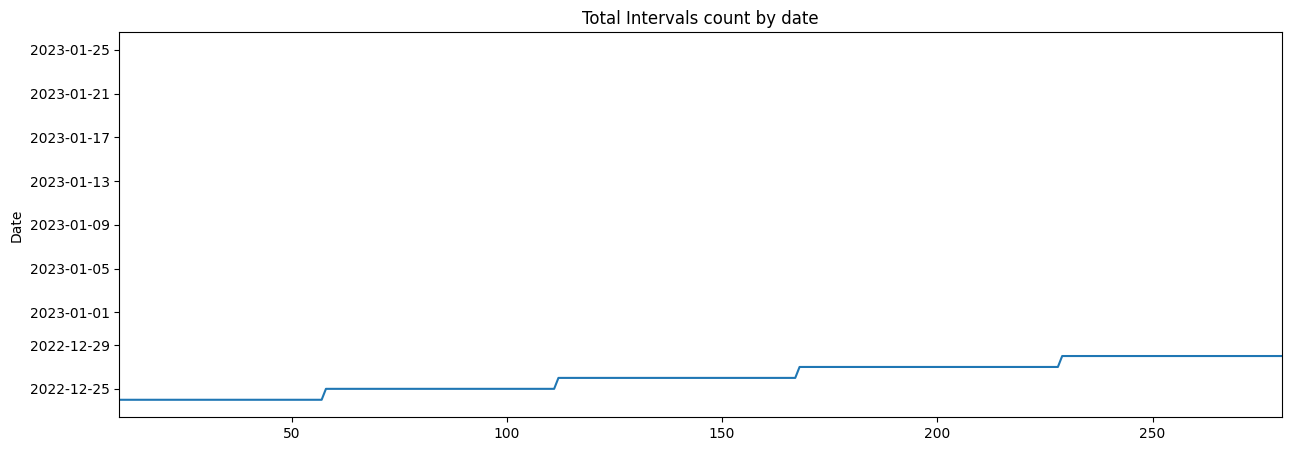

In [11]:
df_tmp = df.loc[:, ['INTERVALDATE', 'TOTALINTERVALS']]

df_tmp["INTERVALDATE"].plot(style="-", figsize=(15, 5), title="Total Intervals count by date")
plt.ylabel('Date')

plt.xlim(10, 280)

plt.show()

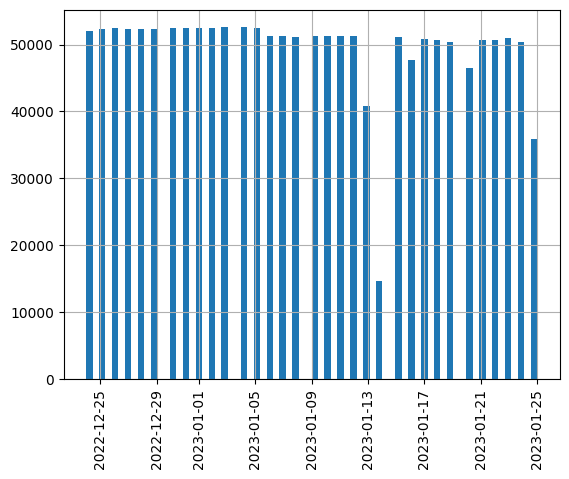

In [27]:
df_tmp["INTERVALDATE"].hist(bins=70)
plt.xticks(rotation='vertical') 
plt.show()

In [12]:
df_tmp[df_tmp["INTERVALDATE"] == '2022-12-25'].count()

INTERVALDATE      52378
TOTALINTERVALS    52378
dtype: int64

In [13]:
df_tmp['INTERVALDATE'].dt.day
df_tmp['day'] = df_tmp['INTERVALDATE'].dt.day

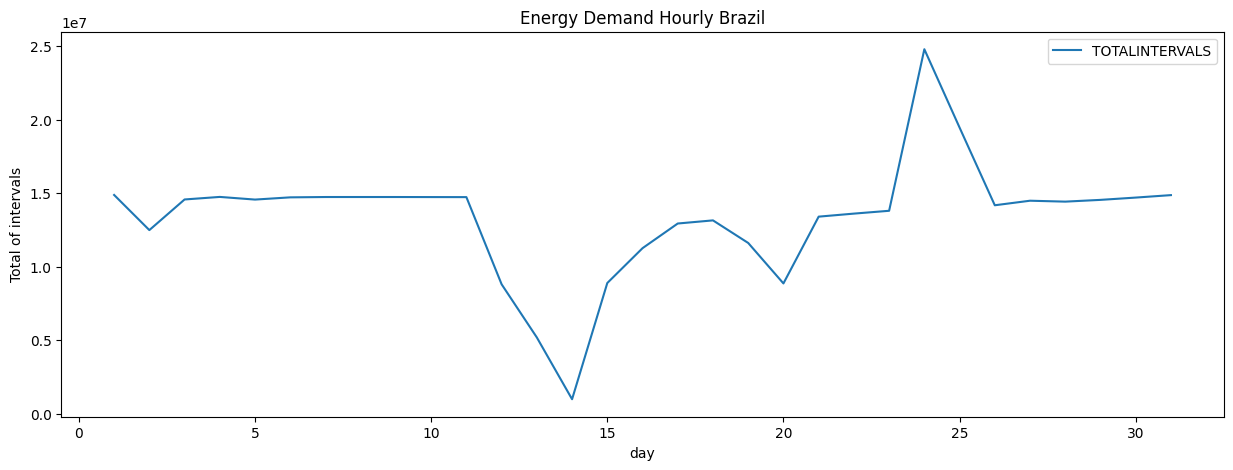

In [14]:
df_day = df_tmp.groupby('day')[['TOTALINTERVALS']].sum()

df_day[["TOTALINTERVALS"]].plot(style="-", figsize=(15, 5), title="Energy Demand Hourly Brazil")
plt.ylabel('Total of intervals')
plt.show()

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [77]:
df.head()

,ENDPOINTID,METERID,METERNO,INTERVALDATE,INTERVALCHANNELNO,PUBLISHEDPACKET,GAPREQPACKET,TOTALINTERVALS,INFORMATION,INFORMATIONPERCENT,GAPREQEFFICIENCY,DAY,YEAR,MONTH
0,11380,17267,23188146,2022-12-24,5,287.0,0.0,287.0,Incomplete,99.65,0.0,24,2022,12
1,6401,12289,23188738,2022-12-24,9,287.0,0.0,287.0,Incomplete,99.65,0.0,24,2022,12
2,11706,17593,31024264,2022-12-24,2,257.0,0.0,257.0,Incomplete,89.24,0.0,24,2022,12
3,10864,16751,23189052,2022-12-24,3,173.0,0.0,173.0,Incomplete,60.07,0.0,24,2022,12
4,7635,13523,23189778,2022-12-24,7,287.0,0.0,287.0,Incomplete,99.65,0.0,24,2022,12


In [18]:
df_1 = df
df_1 = df_1.drop(columns=['METERNO'])
df_1 = df_1.drop(columns=['METERID'])
df_1 = df_1.drop(columns=['INTERVALDATE'])
df_1 = df_1.drop(columns=['INFORMATION'])
df_1['DAY'] = df['INTERVALDATE'].dt.day
df_1['MONTH'] = df['INTERVALDATE'].dt.month
df_1['YEAR'] = df['INTERVALDATE'].dt.year
df_1['GAPREQEFFICIENCY'] = df_1['GAPREQEFFICIENCY'].fillna(0)

In [93]:
df_1.head()

,ENDPOINTID,INTERVALCHANNELNO,PUBLISHEDPACKET,GAPREQPACKET,TOTALINTERVALS,INFORMATIONPERCENT,GAPREQEFFICIENCY,DAY,YEAR,MONTH
0,11380,5,287.0,0.0,287.0,99.65,0.0,24,2022,12
1,6401,9,287.0,0.0,287.0,99.65,0.0,24,2022,12
2,11706,2,257.0,0.0,257.0,89.24,0.0,24,2022,12
3,10864,3,173.0,0.0,173.0,60.07,0.0,24,2022,12
4,7635,7,287.0,0.0,287.0,99.65,0.0,24,2022,12


In [19]:
#Prepare features (X) and target (y)
X = df_1[['ENDPOINTID', 'DAY', 'MONTH', 'YEAR', 'INTERVALCHANNELNO', 'PUBLISHEDPACKET', 'GAPREQPACKET', 'TOTALINTERVALS', 'INFORMATIONPERCENT']]
y = df_1['GAPREQEFFICIENCY']

In [20]:
# Split the data into train and test sets
train_data = df_1.sample(frac=0.9, random_state=42)  # 90% training
test_data = df_1.drop(train_data.index)             # 10% testing

In [21]:
X_train = train_data[['ENDPOINTID', 'DAY', 'MONTH', 'YEAR', 'INTERVALCHANNELNO', 'PUBLISHEDPACKET', 'GAPREQPACKET', 'TOTALINTERVALS', 'INFORMATIONPERCENT']]
y_train = train_data['GAPREQEFFICIENCY']

X_test = test_data[['ENDPOINTID', 'DAY', 'MONTH', 'YEAR', 'INTERVALCHANNELNO', 'PUBLISHEDPACKET', 'GAPREQPACKET', 'TOTALINTERVALS', 'INFORMATIONPERCENT']]
y_test = test_data["GAPREQEFFICIENCY"]

In [25]:
# Train the model
model = RandomForestRegressor(
    n_estimators=100,      # Number of trees in the forest
    max_depth=None,        # Trees expand until leaves are pure
    min_samples_split=2,   # Minimum samples required to split a node
    random_state=42,       # Ensures reproducible results
    n_jobs=-1              # Use all available CPU cores for parallel processing
)

model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [26]:
# Test the model
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [27]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)

r2 = r2_score(y_test, y_pred_test)

In [28]:
# Print accuracy metrics
print(f"Train MSE: {mse:.2f}")
print(f"Test MAE: {mae:.2f}")
print(f"R2 Score: {r2}")

Train MSE: 0.00
Test MAE: 0.00
R2 Score: 0.9999998313829984


<function matplotlib.pyplot.show(close=None, block=None)>

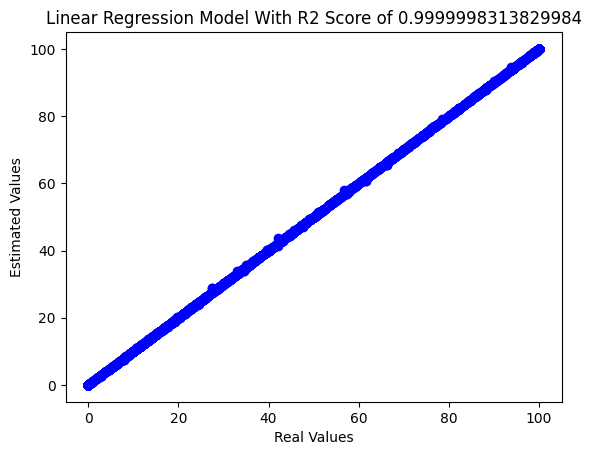

In [29]:
plt.scatter(x = y_test, y = y_pred_test, color = "b")
plt.xlabel("Real Values")
plt.ylabel("Estimated Values")
plt.title(f"Random Forest Regressor Model With R2 Score of {r2}")
plt.show